# Industrial Surface Defect Detection Using Deep Learning and Explainable AI

## Final Project Summary — MVTec AD Tile

This presentation-ready notebook synthesizes the executed project artifacts. It does not retrain models, recalibrate thresholds, or re-evaluate the test set.

## 1. Problem and operational objective

Industrial visual inspection must detect surface defects while controlling unnecessary manual review. This project reformulates the MVTec AD Tile category as supervised binary classification: **Good** versus **Defective**. The final system adds Grad-CAM explanations and a three-state decision policy: Good, Defective, or Needs Human Review.

MVTec AD was designed for unsupervised anomaly detection. The supervised reformulation is therefore a project-specific methodological choice and a documented limitation.

In [2]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
PROJECT_ROOT=Path.cwd().resolve()
frozen=json.loads((PROJECT_ROOT/'outputs/analysis/milestone3/validation_threshold_selection_summary.json').read_text())
fine=json.loads((PROJECT_ROOT/'outputs/analysis/milestone5/fine_tuned_threshold_selection_summary.json').read_text())
test=json.loads((PROJECT_ROOT/'outputs/analysis/milestone7/final_test_evaluation_summary.json').read_text())
gradcam=json.loads((PROJECT_ROOT/'outputs/analysis/milestone6/gradcam_summary.json').read_text())
print('Executed artifact summaries loaded successfully.')

Executed artifact summaries loaded successfully.


## 2. Leakage-safe methodology

- Original-image-level train, validation, and test assignments with seed 42.
- Duplicate hash and group isolation checks before model training.
- Augmentation applied only to training batches.
- Custom CNN baseline followed by ImageNet-pretrained MobileNetV2.
- Controlled fine-tuning of the last 20 backbone layers; BatchNormalization remained frozen.
- Thresholds selected exclusively on validation data.
- Reserved test split evaluated once after model and thresholds were locked.

In [5]:
comparison=pd.DataFrame([
 {'Model':'Custom CNN baseline','Split':'Validation','Accuracy':0.2592593,'Precision':0.2592593,'Recall':1.0,'ROC-AUC':0.7607143,'PR-AUC':0.4457846,'Notes':'Best checkpoint; severe overfitting'},
 {'Model':'Frozen MobileNetV2','Split':'Validation','Accuracy':frozen['default_threshold_metrics']['accuracy'],'Precision':frozen['default_threshold_metrics']['precision'],'Recall':frozen['default_threshold_metrics']['recall'],'ROC-AUC':frozen['validation_roc_auc'],'PR-AUC':frozen['validation_pr_auc'],'Notes':'Threshold 0.50'},
 {'Model':'Fine-tuned MobileNetV2','Split':'Validation','Accuracy':fine['default_threshold_metrics']['accuracy'],'Precision':fine['default_threshold_metrics']['precision'],'Recall':fine['default_threshold_metrics']['recall'],'ROC-AUC':fine['validation_roc_auc'],'PR-AUC':fine['validation_pr_auc'],'Notes':'Threshold 0.50'},
 {'Model':'Fine-tuned MobileNetV2','Split':'Final Test','Accuracy':test['binary_metrics']['accuracy'],'Precision':test['binary_metrics']['precision'],'Recall':test['binary_metrics']['recall'],'ROC-AUC':test['binary_metrics']['roc_auc'],'PR-AUC':test['binary_metrics']['pr_auc'],'Notes':f"Locked threshold {test['binary_metrics']['threshold']:.3f}"}
]).set_index(['Model','Split'])
display(comparison.style.format({'Accuracy':'{:.2%}','Precision':'{:.2%}','Recall':'{:.2%}','ROC-AUC':'{:.3f}','PR-AUC':'{:.3f}'}))

## 3. Model selection and threshold policy

Transfer learning substantially outperformed the custom CNN on the small dataset. Fine-tuning improved validation loss and ranking metrics. The selected binary threshold maximized validation F1 among candidates with defective recall of at least 90%.

The locked thresholds were: binary/Good boundary `0.152666` and automatic-Defective boundary `0.439`. Predictions between these values were assigned to human review.

In [6]:
validation_table=pd.DataFrame({
 'Metric':['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC','Human-review rate','Automatic coverage'],
 'Validation':[fine['selected_threshold_metrics']['accuracy'],fine['selected_threshold_metrics']['precision'],fine['selected_threshold_metrics']['recall'],fine['selected_threshold_metrics']['f1'],fine['validation_roc_auc'],fine['validation_pr_auc'],fine['human_review']['review_rate'],fine['human_review']['automatic_coverage']],
 'Final test':[test['binary_metrics']['accuracy'],test['binary_metrics']['precision'],test['binary_metrics']['recall'],test['binary_metrics']['f1'],test['binary_metrics']['roc_auc'],test['binary_metrics']['pr_auc'],test['human_review']['review_rate'],test['human_review']['automatic_coverage']]
})
display(validation_table.style.format({'Validation':'{:.2%}','Final test':'{:.2%}'}))

,Metric,Validation,Final test
0,Accuracy,94.44%,94.12%
1,Precision,82.35%,90.91%
2,Recall,100.00%,83.33%
3,F1,90.32%,86.96%
4,ROC-AUC,98.93%,97.44%
5,PR-AUC,97.24%,94.44%
6,Human-review rate,7.41%,1.96%
7,Automatic coverage,92.59%,98.04%


## 4. Final test findings

The locked final test achieved 94.12% accuracy, 90.91% defective precision, 83.33% defective recall, and 86.96% F1. The confusion matrix contained 38 true negatives, 1 false positive, 2 false negatives, and 10 true positives.

The false negatives were one `gray_stroke` image and one `rough` image. Both were automatically marked Good. Consequently, the validation observation of zero automatically accepted defects did not generalize to the test set. The thresholds were not changed after observing this result.

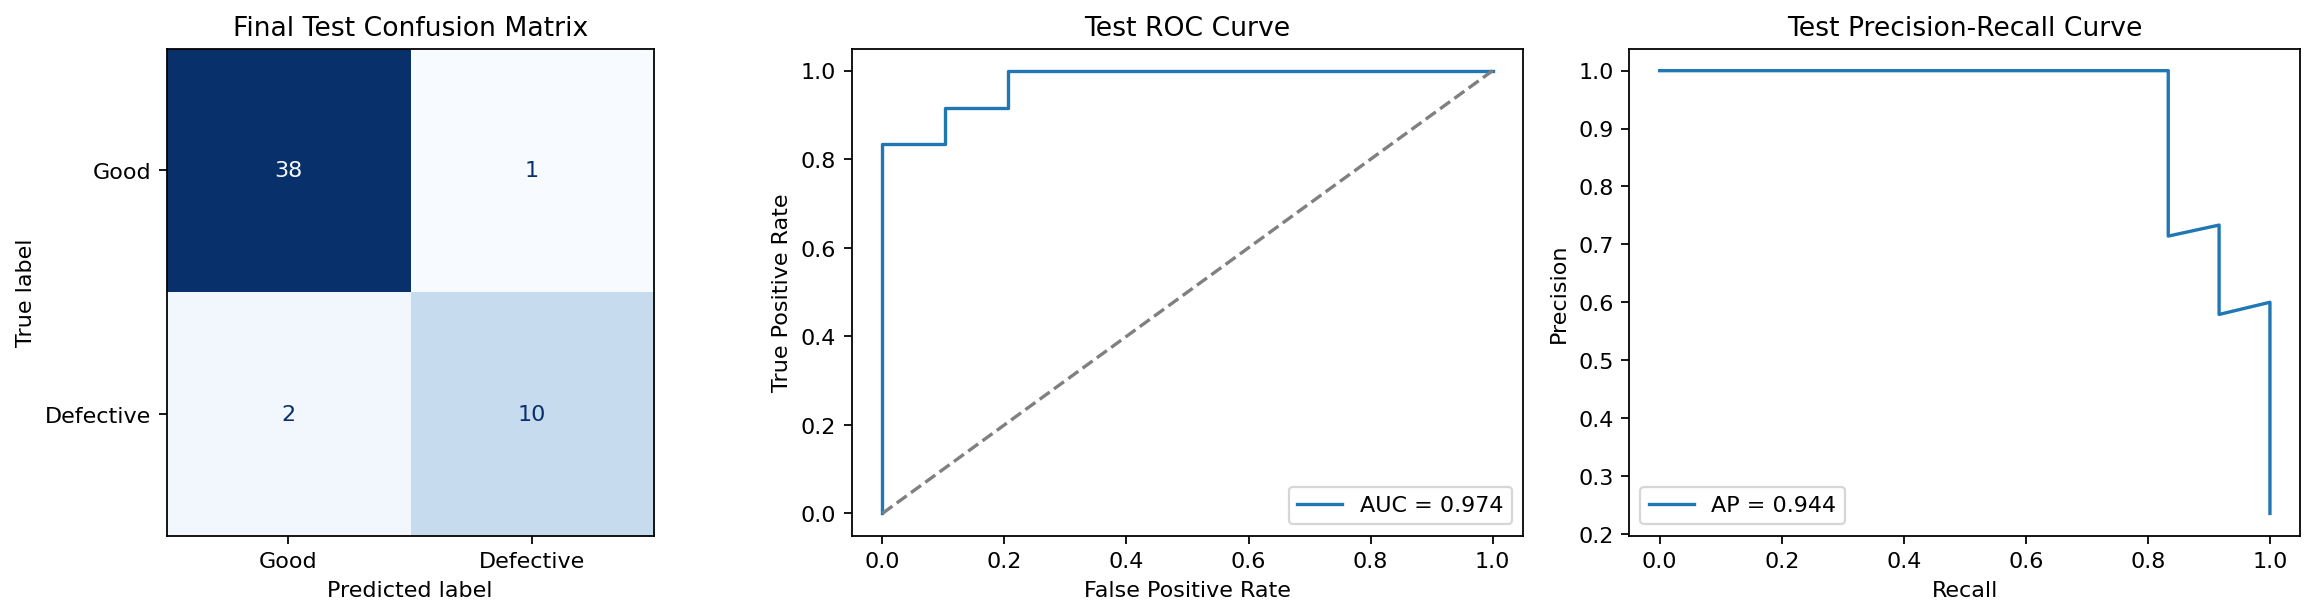

,defect_type,image_count,detected_count,mean_probability,recall
0,crack,2,2,1.000,100.0%
1,glue_strip,3,3,0.978,100.0%
2,gray_stroke,2,1,0.397,50.0%
3,oil,3,3,0.997,100.0%
4,rough,2,1,0.481,50.0%


In [7]:
display(Image(filename=str(PROJECT_ROOT/'outputs/figures/milestone7/final_test_metrics.png')))
display(pd.read_csv(PROJECT_ROOT/'outputs/analysis/milestone7/final_test_per_defect_recall.csv').style.format({'mean_probability':'{:.3f}','recall':'{:.1%}'}))

## 5. Explainability

Grad-CAM was generated at MobileNetV2 layer `Conv_1` for correct Good and Defective predictions, all validation false positives, and low-confidence or review cases. Crack examples showed attention near visible crack structures. False positives often showed diffuse attention over texture or borders. Low-confidence gray-stroke examples showed weaker or partial localization.

Grad-CAM is a coarse gradient-based sensitivity map. It must not be interpreted as causal proof of why the model decided.

Grad-CAM examples: 11 | False negatives available in validation: 0


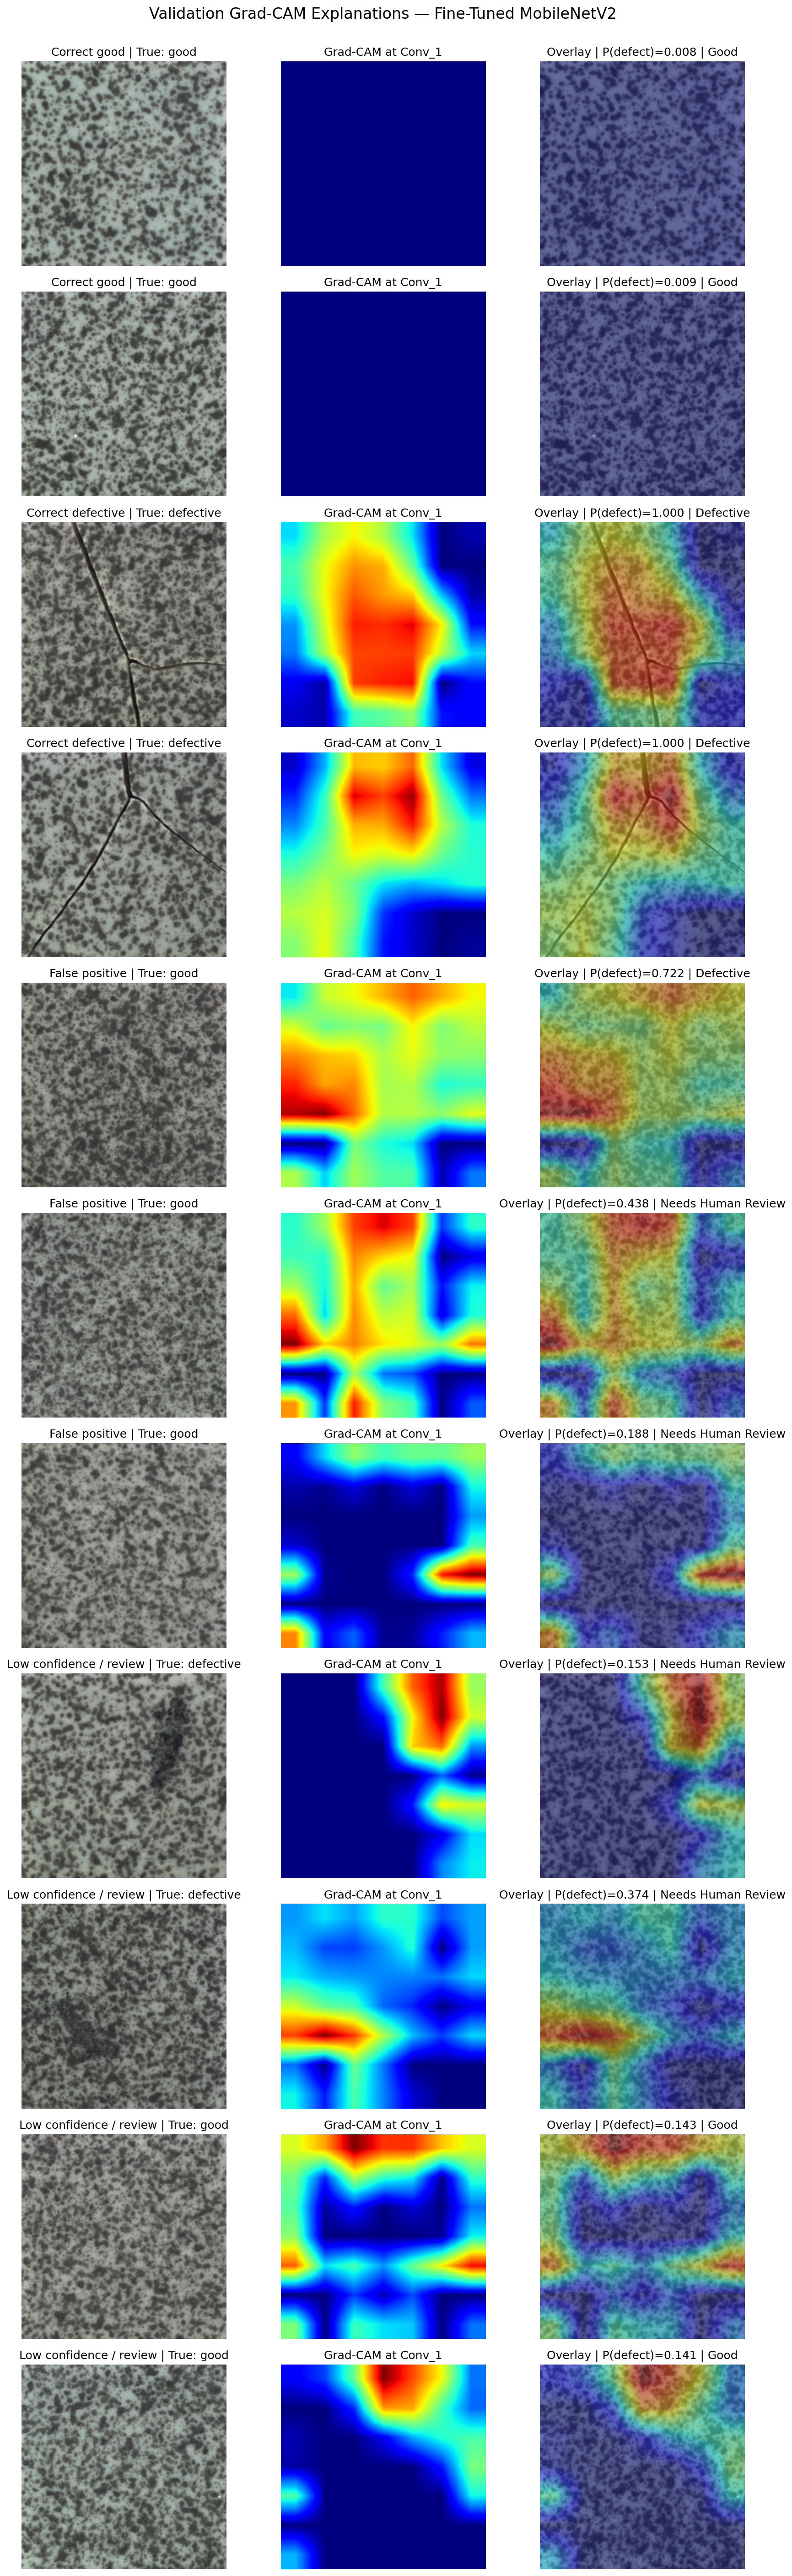

In [8]:
print('Grad-CAM examples:',gradcam['selected_examples'], '| False negatives available in validation:',gradcam['false_negatives_available'])
display(Image(filename=str(PROJECT_ROOT/'outputs/figures/milestone6/gradcam/fine_tuned_validation_gradcam_panel.png'),width=900))

## 6. Limitations and responsible interpretation

- Only 14 defective validation images and 12 defective test images were available.
- Per-defect estimates are especially uncertain; `gray_stroke` and `rough` each had 50% test recall.
- The supervised split is not the original MVTec AD benchmark protocol.
- Confidence thresholds are empirical and did not guarantee safe auto-acceptance on test data.
- The prototype has no production latency, drift, calibration, or field-validation study.
- Grad-CAM does not establish causal explanations.

A production-oriented next study should collect more representative defective images, introduce a new untouched holdout set, evaluate probability calibration, and optimize the review policy under an explicit cost model.

## 7. Conclusion

Transfer learning was appropriate for this small industrial image dataset, consistent with instructor feedback. Controlled fine-tuning produced the strongest validation model and strong final test ranking performance. However, the two final-test false negatives demonstrate why accuracy alone is insufficient and why confidence-based review requires independent validation. The completed project provides a reproducible experimental pipeline, transparent limitations, Grad-CAM diagnostics, and a defensible final evaluation without post-test tuning.